**Problem Statement:**

Build a Machine Learning classification model that predicts whether a patient is likely to have diabetes (Yes/No) based on basic health and medical measurements.

In [ ]:
# import Library
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
df = pd.read_csv('/content/healthcare_diabetes.csv')
df

,Age,Gender,BMI,Glucose,BloodPressure,Insulin,HbA1c,PhysicalActivity,FamilyHistory,Diabetes
0,39,Male,23.7,143.0,113.0,133.0,5.4,Medium,No,1
1,49,Male,27.1,113.0,158.0,129.0,5.2,High,No,0
2,36,Female,29.0,95.0,122.0,114.0,4.5,High,No,0
3,70,Female,28.0,115.0,81.0,104.0,5.3,High,No,0
4,33,Female,27.7,105.0,137.0,NaN,5.6,High,No,0
...,...,...,...,...,...,...,...,...,...,...
4995,51,Female,24.9,144.0,138.0,161.0,5.7,Medium,No,1
4996,44,Male,23.0,155.0,147.0,NaN,5.8,Medium,No,1
4997,62,Female,27.1,150.0,159.0,157.0,5.8,Medium,Yes,1
4998,54,Male,25.9,118.0,148.0,154.0,5.1,Medium,No,0


In [ ]:
df.shape

(5000, 10)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 10 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Age               5000 non-null   int64  
 1   Gender            5000 non-null   object 
 2   BMI               4850 non-null   float64
 3   Glucose           4875 non-null   float64
 4   BloodPressure     4875 non-null   float64
 5   Insulin           4700 non-null   float64
 6   HbA1c             4875 non-null   float64
 7   PhysicalActivity  4900 non-null   object 
 8   FamilyHistory     4900 non-null   object 
 9   Diabetes          5000 non-null   int64  
dtypes: float64(5), int64(2), object(3)
memory usage: 390.8+ KB


In [ ]:
df.describe()

,Age,BMI,Glucose,BloodPressure,Insulin,HbA1c,Diabetes
count,5000.00000,4850.000000,4875.000000,4875.000000,4700.000000,4875.000000,5000.000000
mean,47.80560,25.951897,138.790359,142.000000,136.171489,5.644226,0.797800
std,14.58067,4.587394,22.726134,14.524186,62.052020,0.860934,0.401681
min,18.00000,15.200000,46.000000,66.000000,14.000000,3.000000,0.000000
25%,38.00000,22.900000,126.000000,133.000000,106.000000,5.200000,1.000000
50%,48.00000,25.700000,138.000000,142.000000,131.000000,5.600000,1.000000
75%,57.00000,28.675000,150.000000,151.000000,158.000000,5.900000,1.000000
max,85.00000,54.400000,346.000000,219.000000,788.000000,14.800000,1.000000


In [ ]:
df.head()

,Age,Gender,BMI,Glucose,BloodPressure,Insulin,HbA1c,PhysicalActivity,FamilyHistory,Diabetes
0,39,Male,23.7,143.0,113.0,133.0,5.4,Medium,No,1
1,49,Male,27.1,113.0,158.0,129.0,5.2,High,No,0
2,36,Female,29.0,95.0,122.0,114.0,4.5,High,No,0
3,70,Female,28.0,115.0,81.0,104.0,5.3,High,No,0
4,33,Female,27.7,105.0,137.0,NaN,5.6,High,No,0


In [ ]:
df.tail()

,Age,Gender,BMI,Glucose,BloodPressure,Insulin,HbA1c,PhysicalActivity,FamilyHistory,Diabetes
4995,51,Female,24.9,144.0,138.0,161.0,5.7,Medium,No,1
4996,44,Male,23.0,155.0,147.0,NaN,5.8,Medium,No,1
4997,62,Female,27.1,150.0,159.0,157.0,5.8,Medium,Yes,1
4998,54,Male,25.9,118.0,148.0,154.0,5.1,Medium,No,0
4999,33,Female,19.0,153.0,142.0,92.0,5.9,Low,Yes,1


In [ ]:
df.isnull().sum()

,0
Age,0
Gender,0
BMI,150
Glucose,125
BloodPressure,125
Insulin,300
HbA1c,125
PhysicalActivity,100
FamilyHistory,100
Diabetes,0


In [ ]:
df.dtypes

,0
Age,int64
Gender,object
BMI,float64
Glucose,float64
BloodPressure,float64
Insulin,float64
HbA1c,float64
PhysicalActivity,object
FamilyHistory,object
Diabetes,int64


In [ ]:
numerical_cols = [
    "BMI",
    "Glucose",
    "BloodPressure",
    "Insulin",
    "HbA1c"
]

for col in numerical_cols:
    df[col] = df[col].fillna(df[col].mean())

In [ ]:
categorical_cols = [
    "PhysicalActivity",
    "FamilyHistory"
]

for col in categorical_cols:
    df[col] = df[col].fillna(df[col].mode()[0])

In [ ]:
df.isnull().sum()

,0
Age,0
Gender,0
BMI,0
Glucose,0
BloodPressure,0
Insulin,0
HbA1c,0
PhysicalActivity,0
FamilyHistory,0
Diabetes,0


In [ ]:
df

,Age,Gender,BMI,Glucose,BloodPressure,Insulin,HbA1c,PhysicalActivity,FamilyHistory,Diabetes
0,39,Male,23.7,143.0,113.0,133.000000,5.4,Medium,No,1
1,49,Male,27.1,113.0,158.0,129.000000,5.2,High,No,0
2,36,Female,29.0,95.0,122.0,114.000000,4.5,High,No,0
3,70,Female,28.0,115.0,81.0,104.000000,5.3,High,No,0
4,33,Female,27.7,105.0,137.0,136.171489,5.6,High,No,0
...,...,...,...,...,...,...,...,...,...,...
4995,51,Female,24.9,144.0,138.0,161.000000,5.7,Medium,No,1
4996,44,Male,23.0,155.0,147.0,136.171489,5.8,Medium,No,1
4997,62,Female,27.1,150.0,159.0,157.000000,5.8,Medium,Yes,1
4998,54,Male,25.9,118.0,148.0,154.000000,5.1,Medium,No,0


In [ ]:
df.duplicated().sum()

np.int64(0)

In [ ]:
categorical_col = df.select_dtypes(include= "object").columns
categorical_col

Index(['Gender', 'PhysicalActivity', 'FamilyHistory'], dtype='object')

In [ ]:
numerical_col = df.select_dtypes(exclude= "object").columns
numerical_col

Index(['Age', 'BMI', 'Glucose', 'BloodPressure', 'Insulin', 'HbA1c',
       'Diabetes'],
      dtype='object')

In [ ]:
# outlier

for col in numerical_col:
  Q1 = df[col].quantile(0.25)
  Q3 = df[col].quantile(0.75)
  IQR = Q3 - Q1
  lower_bound = Q1 - 1.5 * IQR
  upper_bound = Q3 + 1.5 * IQR

  df = df[(df[col] >= lower_bound) & (df[col] <= upper_bound)]

print(df.shape)


(3634, 10)


([0, 1, 2, 3, 4, 5, 6],
 [Text(0, 0, 'Age'),
  Text(1, 0, 'BMI'),
  Text(2, 0, 'Glucose'),
  Text(3, 0, 'BloodPressure'),
  Text(4, 0, 'Insulin'),
  Text(5, 0, 'HbA1c'),
  Text(6, 0, 'Diabetes')])

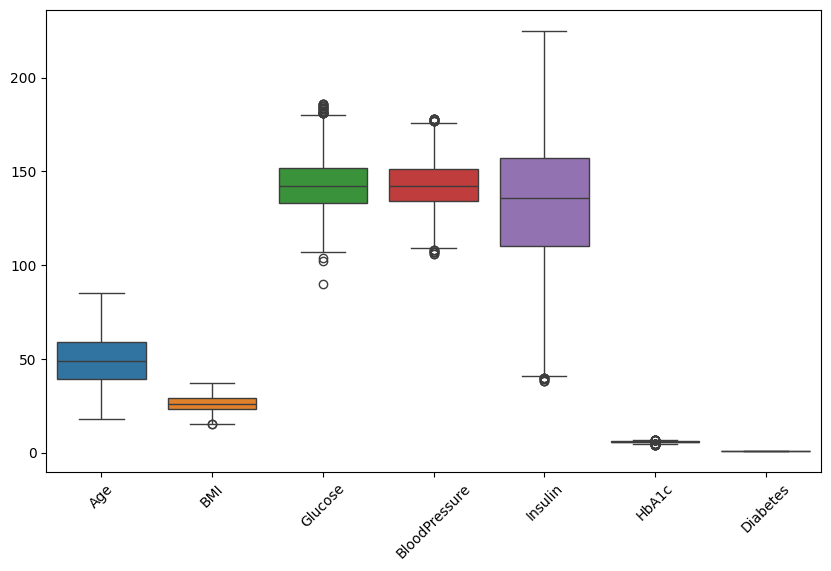

In [ ]:
# Box Plot
plt.figure(figsize=(10, 6))
sns.boxplot(data=df[numerical_col])
plt.xticks(rotation=45)

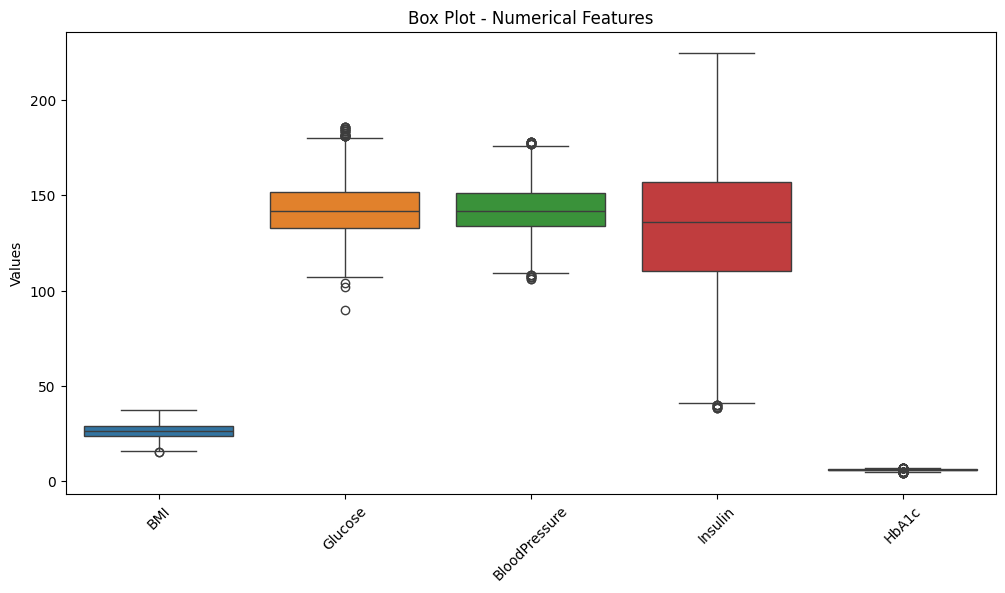

In [ ]:
plt.figure(figsize=(12, 6))

sns.boxplot(data=df[numerical_cols])

plt.title("Box Plot - Numerical Features")
plt.xticks(rotation=45)
plt.ylabel("Values")
plt.show()

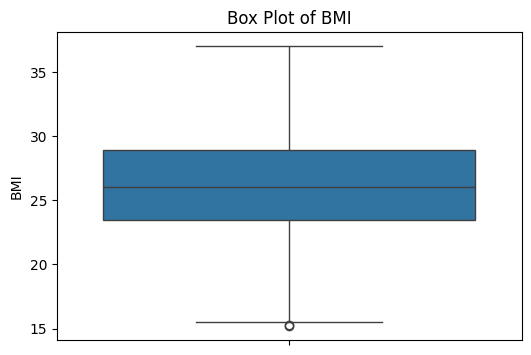

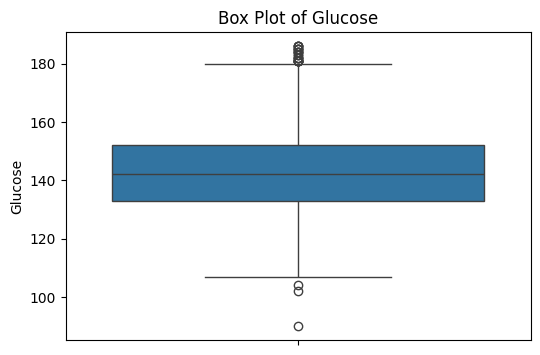

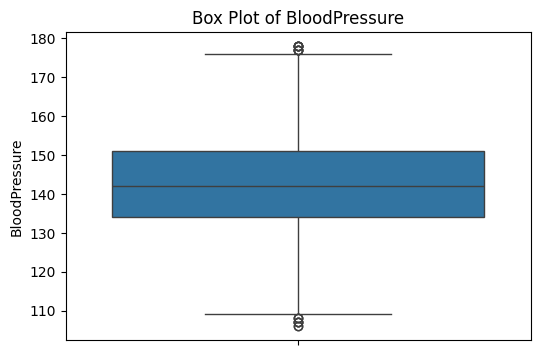

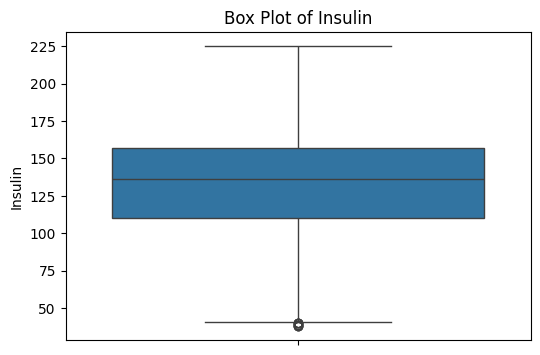

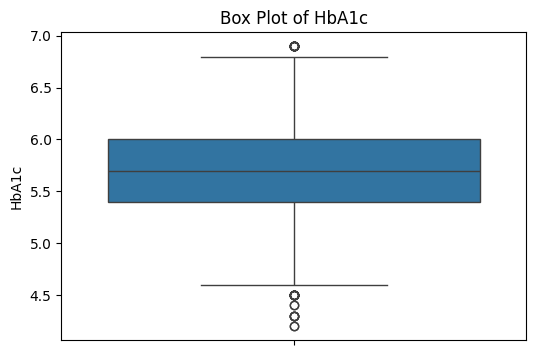

In [ ]:
for col in numerical_cols:
    plt.figure(figsize=(6, 4))

    sns.boxplot(y=df[col])

    plt.title(f"Box Plot of {col}")
    plt.ylabel(col)
    plt.show()

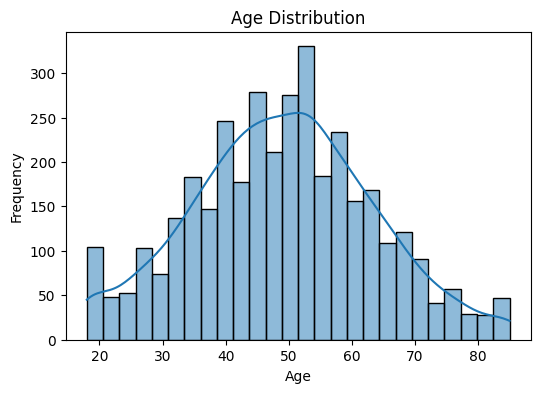

In [ ]:
# Univariate Analysis
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(6,4))
sns.histplot(df["Age"], kde=True)
plt.title("Age Distribution")
plt.xlabel("Age")
plt.ylabel("Frequency")
plt.show()

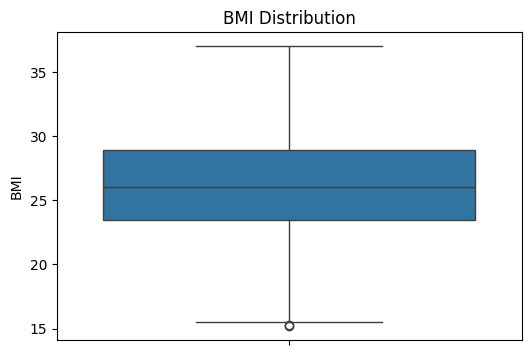

In [ ]:
# BMI
plt.figure(figsize=(6,4))
sns.boxplot(y=df["BMI"])
plt.title("BMI Distribution")
plt.show()

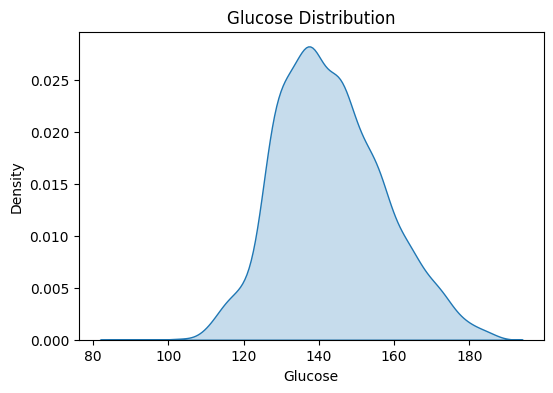

In [ ]:
# Glucose
plt.figure(figsize=(6,4))
sns.kdeplot(df["Glucose"], fill=True)
plt.title("Glucose Distribution")
plt.xlabel("Glucose")
plt.show()

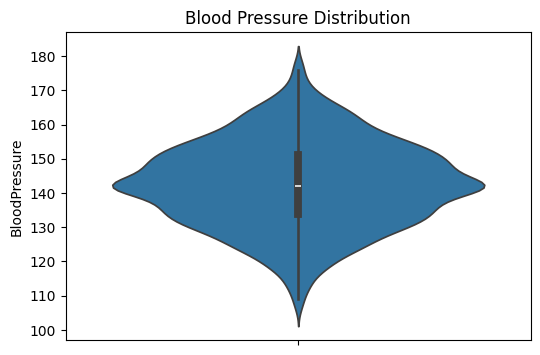

In [ ]:
# Blood Pressure — Violin Plot
plt.figure(figsize=(6,4))
sns.violinplot(y=df["BloodPressure"])
plt.title("Blood Pressure Distribution")
plt.show()

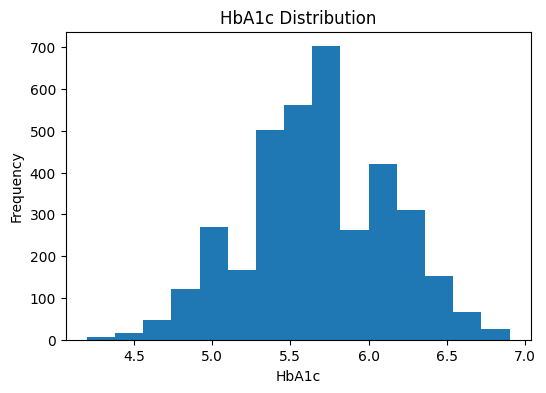

In [ ]:
# HbA1c — Histogram
plt.figure(figsize=(6,4))
plt.hist(df["HbA1c"].dropna(), bins=15)
plt.title("HbA1c Distribution")
plt.xlabel("HbA1c")
plt.ylabel("Frequency")
plt.show()

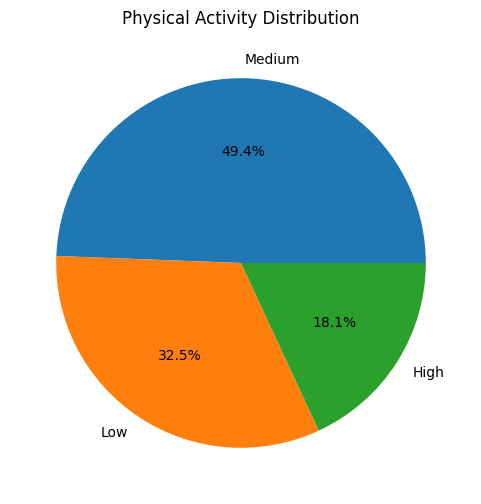

In [ ]:
# Physical Activity — Pie Chart
plt.figure(figsize=(6,6))

df["PhysicalActivity"].value_counts().plot(
    kind="pie",
    autopct="%1.1f%%"
)

plt.title("Physical Activity Distribution")
plt.ylabel("")
plt.show()

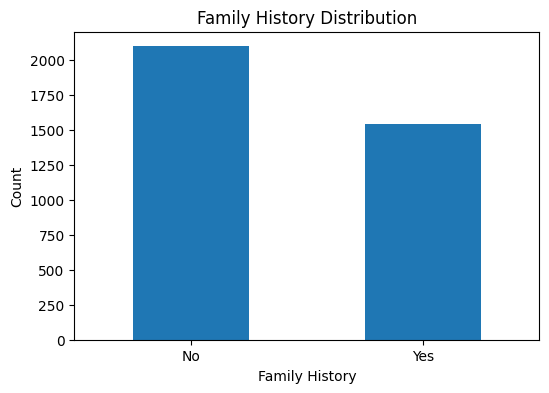

In [ ]:
# Family History — Bar Chart
plt.figure(figsize=(6,4))

df["FamilyHistory"].value_counts().plot(
    kind="bar"
)

plt.title("Family History Distribution")
plt.xlabel("Family History")
plt.ylabel("Count")
plt.xticks(rotation=0)
plt.show()

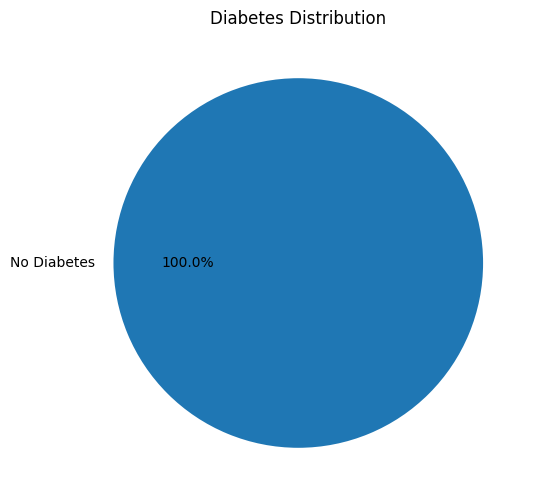

In [ ]:
# Diabetes — Pie Chart
plt.figure(figsize=(6,6))

df["Diabetes"].value_counts().plot(
    kind="pie",
    autopct="%1.1f%%",
    labels=["No Diabetes", "Diabetes"]
)

plt.title("Diabetes Distribution")
plt.ylabel("")
plt.show()

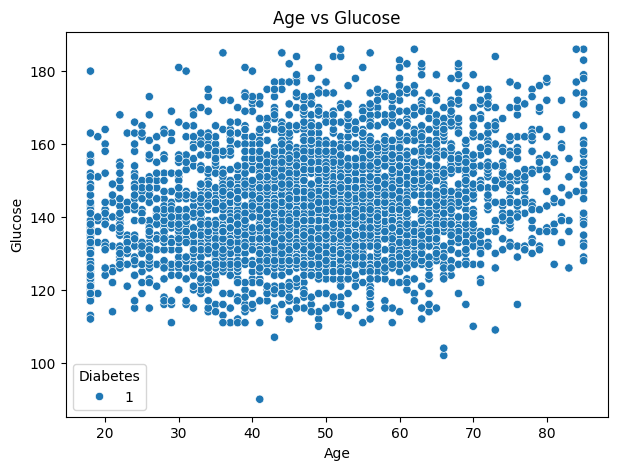

In [ ]:
# Bivariate Analysis
# Age vs Glucose — Scatter Plot
plt.figure(figsize=(7,5))

sns.scatterplot(
    data=df,
    x="Age",
    y="Glucose",
    hue="Diabetes"
)

plt.title("Age vs Glucose")
plt.xlabel("Age")
plt.ylabel("Glucose")
plt.show()

In [ ]:
# Lebel Encoding
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
df["Gender"] = le.fit_transform(df["Gender"])
df["PhysicalActivity"] = le.fit_transform(df["PhysicalActivity"])
df["FamilyHistory"] = le.fit_transform(df["FamilyHistory"])
df



,Age,Gender,BMI,Glucose,BloodPressure,Insulin,HbA1c,PhysicalActivity,FamilyHistory,Diabetes
0,39,1,23.7,143.0,113.0,133.000000,5.4,2,0,1
6,72,0,33.6,142.0,155.0,103.000000,6.3,0,1,1
8,26,1,34.2,151.0,114.0,152.000000,6.5,2,0,1
10,37,1,20.1,128.0,139.0,133.000000,4.9,1,0,1
13,21,0,24.9,146.0,124.0,136.171489,5.9,2,1,1
...,...,...,...,...,...,...,...,...,...,...
4994,65,1,30.3,146.0,167.0,142.000000,6.2,1,1,1
4995,51,0,24.9,144.0,138.0,161.000000,5.7,2,0,1
4996,44,1,23.0,155.0,147.0,136.171489,5.8,2,0,1
4997,62,0,27.1,150.0,159.0,157.000000,5.8,2,1,1


In [ ]:
# Model Building
X = df.drop("Diabetes", axis=1)
y = df["Diabetes"]

In [ ]:
# Train-test split
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X,y,train_size =0.8)

In [ ]:
X_train.shape, X_test.shape, y_train.shape, y_test.shape

((2907, 9), (727, 9), (2907,), (727,))

In [ ]:
X_train.head(5)

,Age,Gender,BMI,Glucose,BloodPressure,Insulin,HbA1c,PhysicalActivity,FamilyHistory
4428,69,0,30.7,176.0,149.0,146.0,6.3,2,1
365,67,0,31.4,124.0,149.0,147.0,5.6,2,0
3942,51,1,22.9,139.0,153.0,119.0,5.7,0,1
4264,73,1,23.2,130.0,153.0,107.0,5.5,0,0
1233,37,0,28.7,141.0,154.0,130.0,6.2,0,1


In [ ]:
# Model initialization
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report


In [ ]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)

X_test_scaled = scaler.transform(X_test)

In [ ]:
model = LogisticRegression()
model

LogisticRegression()

In [ ]:
# Step 4: Model initialization
gnb = GaussianNB()

In [ ]:
# Step 5: Model training
gnb.fit(X_train, y_train)

GaussianNB()

In [ ]:
# Step 6: Predictions
y_pred = gnb.predict(X_test)

In [ ]:
# Step 7: Evaluation
print("✅ Accuracy:", accuracy_score(y_test, y_pred))
print("\n📊 Confusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("\n📈 Classification Report:\n", classification_report(y_test, y_pred))

✅ Accuracy: 1.0

📊 Confusion Matrix:
 [[727]]

📈 Classification Report:
               precision    recall  f1-score   support

           1       1.00      1.00      1.00       727

    accuracy                           1.00       727
   macro avg       1.00      1.00      1.00       727
weighted avg       1.00      1.00      1.00       727



/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:407: UserWarning: A single label was found in 'y_true' and 'y_pred'. For the confusion matrix to have the correct shape, use the 'labels' parameter to pass all known labels.
  warnings.warn(


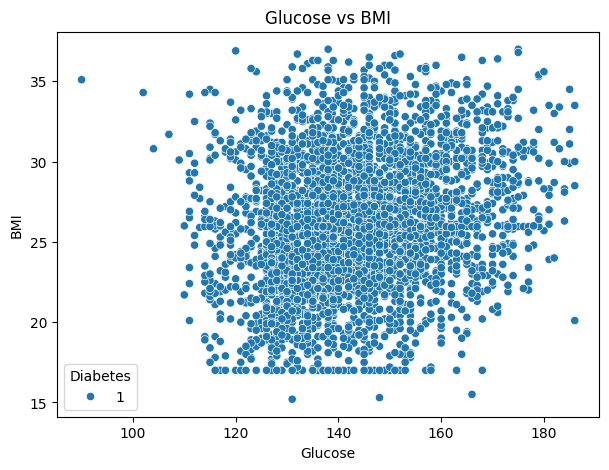

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(7,5))

sns.scatterplot(
    x=df["Glucose"],
    y=df["BMI"],
    hue=df["Diabetes"]
)

plt.title("Glucose vs BMI")
plt.xlabel("Glucose")
plt.ylabel("BMI")
plt.show()

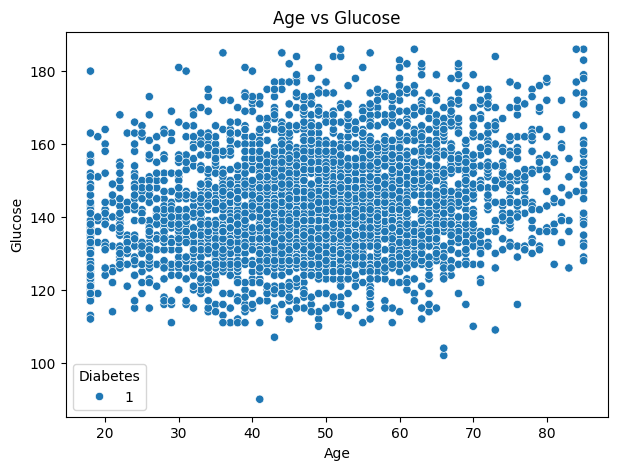

In [ ]:
plt.figure(figsize=(7,5))

sns.scatterplot(
    x=df["Age"],
    y=df["Glucose"],
    hue=df["Diabetes"]
)

plt.title("Age vs Glucose")
plt.xlabel("Age")
plt.ylabel("Glucose")
plt.show()